#Import libraries

In [49]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor


## Loading Dataset




In [50]:
from google.colab import files

uploaded = files.upload()
filename = next(iter(uploaded))
df = pd.read_csv(filename)

Saving Advertising.csv to Advertising (1).csv


Remember to replace `'path/to/your/excel_file.xlsx'` with the correct path to your Excel file. If your Excel file has multiple sheets, you can specify the `sheet_name` parameter in `pd.read_excel()`.

In [51]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


#Data Cleaning

In [52]:
df.shape

(200, 5)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [54]:
df.isnull().sum()

,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
df.drop_duplicates(inplace=True)

In [57]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [58]:
#drop unnamed column

df.drop('Unnamed: 0',axis = 1,inplace = True)

In [59]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


#EDA (Exploratory data analyse)

**Distribution**

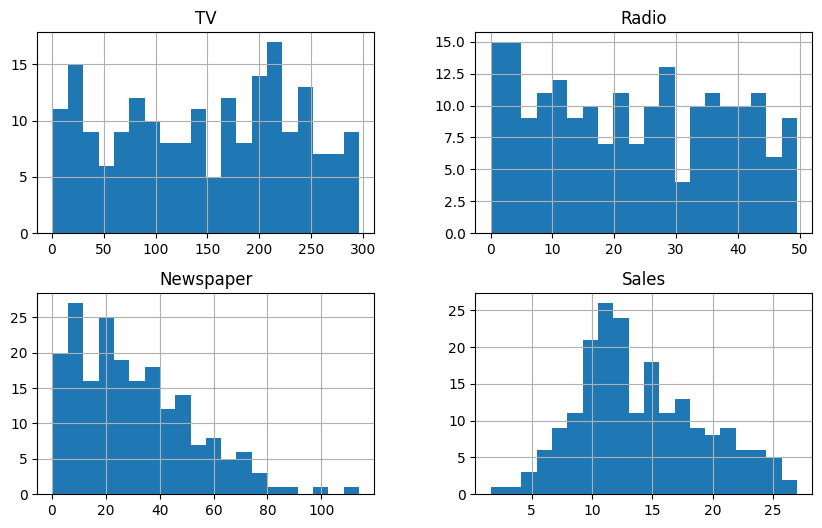

In [60]:
df.hist(bins=20, figsize=(10,6))
plt.show()



**boxplot**

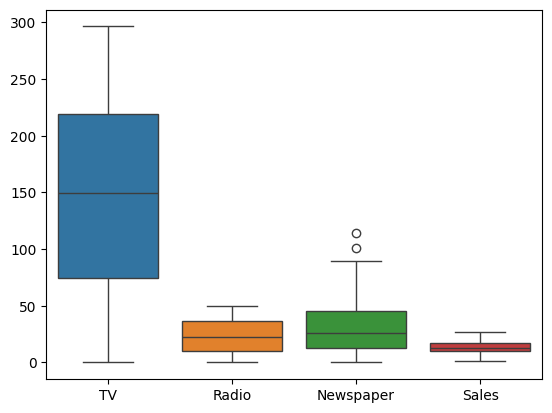

In [61]:
sns.boxplot(data = df)
plt.show()

**Correlation Matrix**

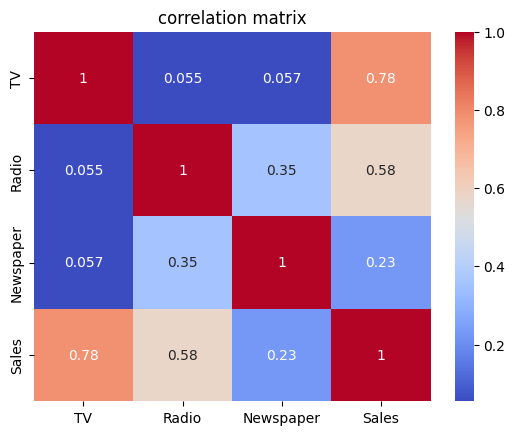

In [62]:
sns.heatmap(df.corr(),annot = True , cmap = 'coolwarm')
plt.title("correlation matrix")
plt.show()

**Interpretation** : Tv advertisement has higher influence on sales where radio contribute but lesser and newspaper adds not cost effective

**Pairplot**

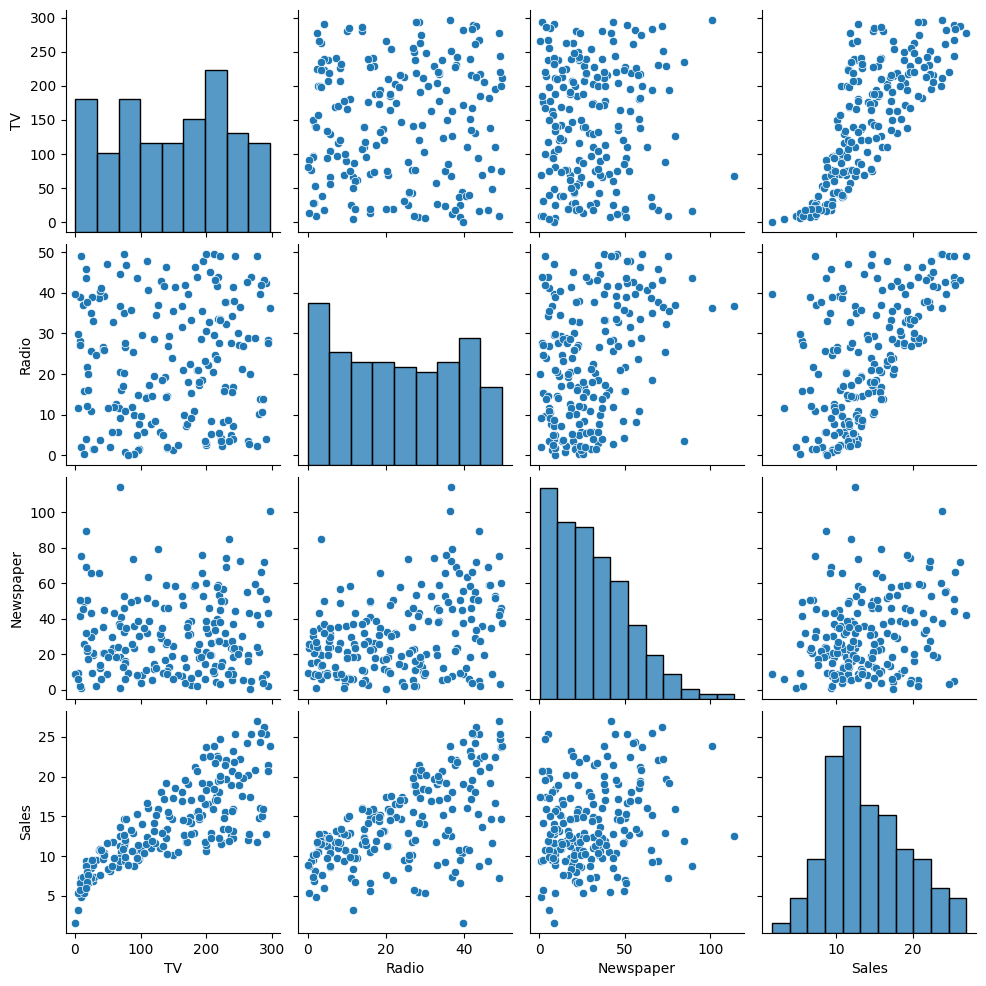

In [63]:
sns.pairplot(df)
plt.show()

**Observation** :

=Tv and sales shows linear upward trend

=Radio vs sales shows moderate trend

=Newspaper vs sales shows appers scatter

#Feature Enginerring

In [64]:
# Total Spend
df['Total_Spend'] = df['TV'] + df['Radio'] + df['Newspaper']

# Interaction Features
df['TV_Radio'] = df['TV'] * df['Radio']
df['TV_Newspaper'] = df['TV'] * df['Newspaper']

#Model Traning

In [65]:
X = df[['TV','Radio','Newspaper','Total_Spend','TV_Radio','TV_Newspaper']]
y = df['Sales']

X_train , X_test , y_train , y_test = train_test_split(X,y,
                                                       test_size = 0.2 ,
                                                       random_state = 42)

#Model Selection





In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [67]:
from sklearn.metrics import mean_squared_error , r2_score
lr_preds = lr_model.predict(X_test)


print("R2 Score:", r2_score(y_test, lr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))

R2 Score: 0.9752684459298699
RMSE: 0.8835251696899996


#Random Forest Regressor

In [68]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor()
rf_model.fit(X_train , y_train)

RandomForestRegressor()

In [69]:
rf_preds = rf_model.predict(X_test)

print("R2 Score:", r2_score(y_test, rf_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))

R2 Score: 0.9888840256030732
RMSE: 0.5923344494455803


**The Random Forest Regressor achieved an R² score of 0.989 and an RMSE of 0.587, indicating high predictive accuracy and low error**

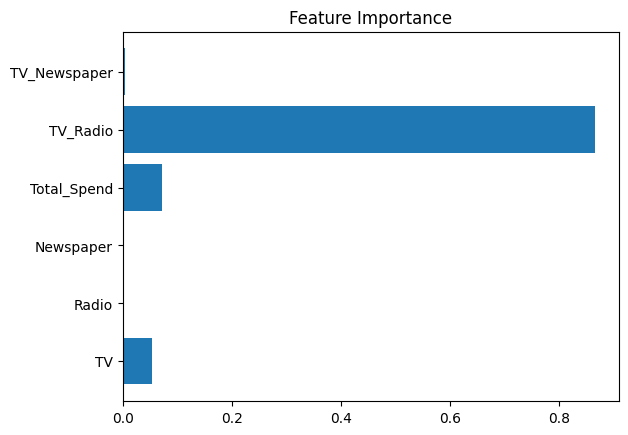

In [70]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [71]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": rf_preds
})

print(results.head(10))

     Actual  Predicted
95     16.9     16.981
15     22.4     22.472
30     21.4     21.230
158     7.3      6.845
128    24.7     23.535
115    12.6     13.052
69     22.3     22.479
170     8.4      9.220
174    11.5     11.866
45     14.9     15.600


#Advertising Impact Analysis


---
**Key observations**


*   TV advertising shows the strongest positive impact on
*   Radio advertising has moderate influence
*   Newspaper advertising shows minimal contribution

**Interpretation**

*   Increasing TV ad spend leads to a significant increase in sales
*   Radio ads are useful but less impactful than TV
*   Newspaper ads do not strongly influence customer purchase behavior






#Business Insights:



---





**High impact channel:**
TV is the most effective advertising medium and should be prioritized.

**Supporting Channel:**
Radio can be used to enhance reach and support campaigns.

**Low-Performance Channel:**
Newspaper advertising provides low returns and should be reduced or optimized.





#Marketing Statergy

**Budget allocation statergy:**


*    50-60% on the TV advertisment
*    20-30% on the Radio advertisment
*    10-20% on the Digital Experimental Statergy
*    Minimum Newpapaer spend


**Campainion Statergy:**


*   Focus campaigns based on customer segments
*   Customize messaging for better engagement

**Optimization Strategy:**


*  Monitor ROI for each channel
*  Shift budget dynamically toward high-performing channels












#Save Model

In [85]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("Model saved successfully")

Model saved successfully
